In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks


file_path = "../../data/raw/WESAD/S2/S2_respiban.txt"

data = pd.read_csv(
    file_path,
    sep="\t",        # change to " " if space-separated
    header=None,
    comment="#",     # ignores metadata lines starting with #
)

print(data.head())
print(data.shape)

   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN
(4442067, 11)


            Metric        Raw   Filtered  % Change
0       ACC X-Mean 36795.6359    -0.0002 -100.0000
1        ACC X-Std   866.3968   126.0645  -85.4496
2      ACC X-Noise    10.5164     7.4446  -29.2100
3      ACC X-Drift  -507.3641     0.3209 -100.0632
4   ACC X-Outliers  3240.0000 60844.0000 1777.9012
5  ACC X-Slope Var    10.5164     7.4446  -29.2100
0       ACC Y-Mean 32333.3972     0.0002 -100.0000
1        ACC Y-Std   316.2120    76.1015  -75.9334
2      ACC Y-Noise     9.2784     5.8051  -37.4345
3      ACC Y-Drift   -36.6028     0.1244 -100.3398
4   ACC Y-Outliers 31668.0000 75654.0000  138.8973
5  ACC Y-Slope Var     9.2784     5.8051  -37.4345
0       ACC Z-Mean 30920.1572     0.0003 -100.0000
1        ACC Z-Std  1478.9737   100.0832  -93.2329
2      ACC Z-Noise    17.1304    11.6906  -31.7551
3      ACC Z-Drift  -505.8428     0.6902 -100.1364
4   ACC Z-Outliers  3054.0000 58620.0000 1819.4499
5  ACC Z-Slope Var    17.1304    11.6906  -31.7551


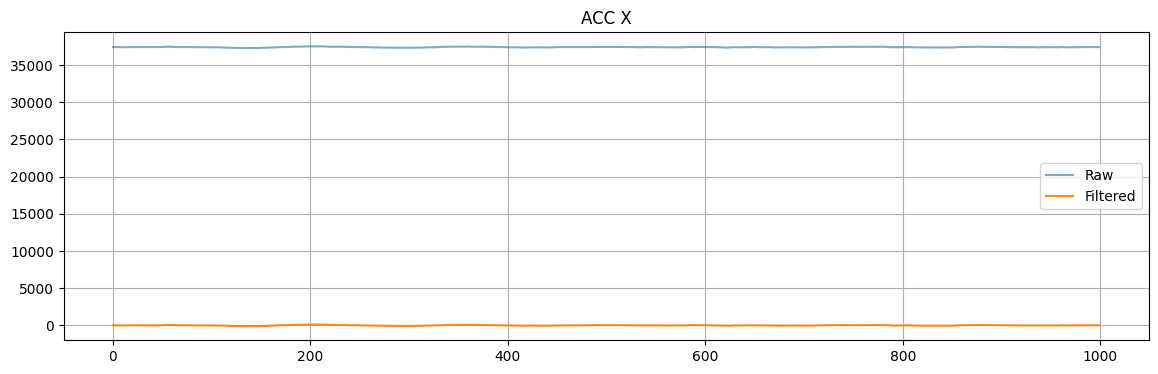

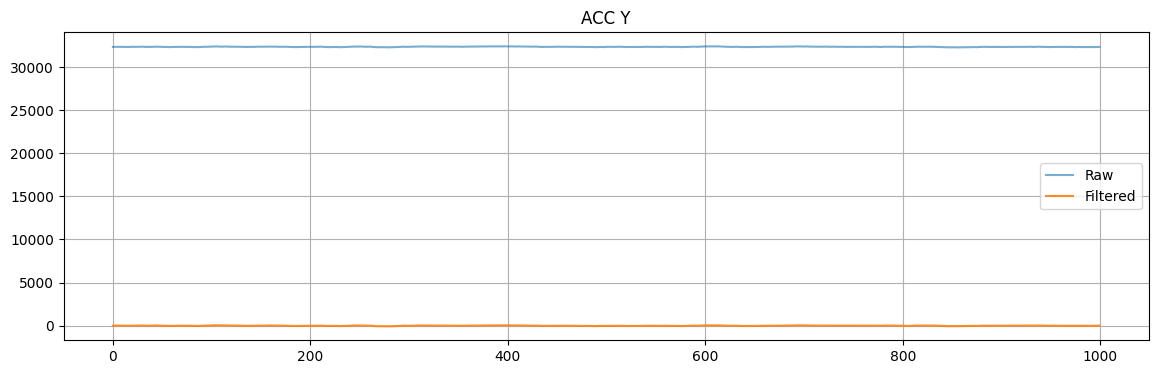

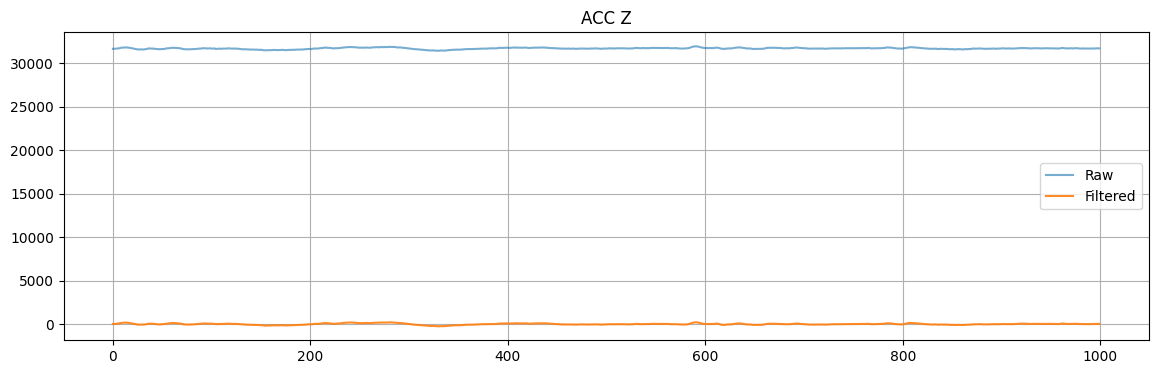

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
 
# =========================================================
# 2. EXTRACT ACC (INDEX 6,7,8 = X,Y,Z)
# =========================================================
acc_x = data.iloc[:, 6].values.astype(float)
acc_y = data.iloc[:, 7].values.astype(float)
acc_z = data.iloc[:, 8].values.astype(float)

# =========================================================
# 3. FILTER (Bandpass for motion signals)
# =========================================================
def bandpass(x, fs=50, low=0.1, high=10):
    nyq = 0.5 * fs
    b, a = butter(3, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, x)

acc_x_f = bandpass(acc_x)
acc_y_f = bandpass(acc_y)
acc_z_f = bandpass(acc_z)

# =========================================================
# 4. METRICS FUNCTION
# =========================================================
def metrics(x):
    return {
        "Mean": np.mean(x),
        "Std": np.std(x),
        "Noise": np.std(np.diff(x)),
        "Drift": np.mean(x) - np.median(x),
        "Outliers": np.sum(np.abs((x - np.mean(x)) / (np.std(x)+1e-6)) > 3),
        "Slope Var": np.std(np.diff(x))
    }

def pct(raw, filt):
    return ((filt - raw) / (raw + 1e-6)) * 100

# =========================================================
# 5. TABLE GENERATOR
# =========================================================
def make_table(name, raw, filt):
    r = metrics(raw)
    f = metrics(filt)

    rows = []
    for k in r.keys():
        rows.append([f"{name}-{k}", r[k], f[k], pct(r[k], f[k])])

    return pd.DataFrame(rows, columns=["Metric", "Raw", "Filtered", "% Change"])

acc_x_table = make_table("ACC X", acc_x, acc_x_f)
acc_y_table = make_table("ACC Y", acc_y, acc_y_f)
acc_z_table = make_table("ACC Z", acc_z, acc_z_f)

acc_table = pd.concat([acc_x_table, acc_y_table, acc_z_table])

print(acc_table)

# =========================================================
# 6. PLOT (ZOOMED RAW VS FILTERED)
# =========================================================
def plot(raw, filt, title):
    plt.figure(figsize=(14,4))
    plt.plot(raw[:1000], label="Raw", alpha=0.6)
    plt.plot(filt[:1000], label="Filtered", alpha=0.9)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

plot(acc_x, acc_x_f, "ACC X")
plot(acc_y, acc_y_f, "ACC Y")
plot(acc_z, acc_z_f, "ACC Z")

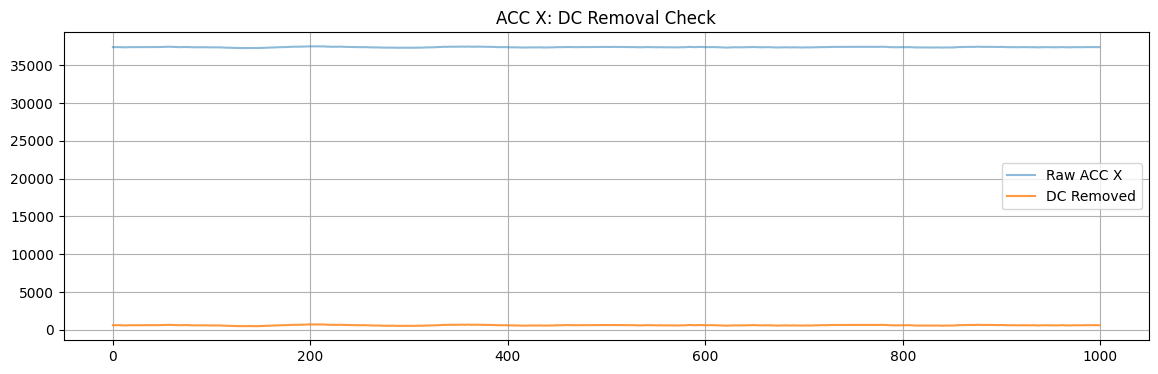

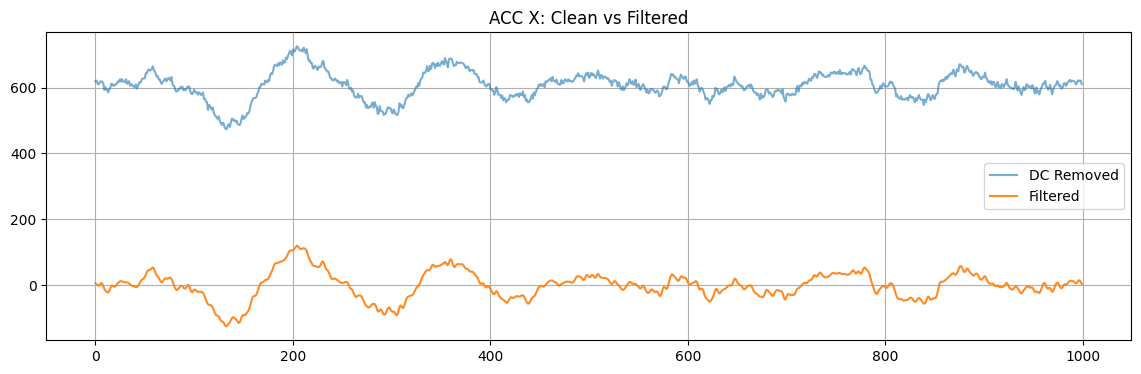

In [47]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

 
acc_x = data.iloc[:, 6].values.astype(float)
acc_y = data.iloc[:, 7].values.astype(float)
acc_z = data.iloc[:, 8].values.astype(float)

# clean
acc_x = np.nan_to_num(acc_x)
acc_y = np.nan_to_num(acc_y)
acc_z = np.nan_to_num(acc_z)

# =========================================================
# 2. REMOVE DC OFFSET (IMPORTANT STEP)
# =========================================================
raw_dc = acc_x - np.mean(acc_x)
filt_dc = acc_x_f - np.mean(acc_x_f)
def remove_dc(x):
    return x - np.mean(x)

acc_x_dc = remove_dc(acc_x)
acc_y_dc = remove_dc(acc_y)
acc_z_dc = remove_dc(acc_z)

# =========================================================
# 3. BANDPASS FILTER (motion only)
# =========================================================
def bandpass(x, fs=50, low=0.1, high=10):
    nyq = 0.5 * fs
    b, a = butter(3, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, x)

acc_x_f = bandpass(acc_x_dc)
acc_y_f = bandpass(acc_y_dc)
acc_z_f = bandpass(acc_z_dc)

# =========================================================
# 4. PLOT CHECK (DC vs CLEANED)
# =========================================================
plt.figure(figsize=(14,4))
plt.plot(acc_x[:1000], label="Raw ACC X", alpha=0.5)
plt.plot(acc_x_dc[:1000], label="DC Removed", alpha=0.8)
plt.title("ACC X: DC Removal Check")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# 5. FINAL RAW vs FILTERED
# =========================================================
plt.figure(figsize=(14,4))
plt.plot(acc_x_dc[:1000], label="DC Removed", alpha=0.6)
plt.plot(acc_x_f[:1000], label="Filtered", alpha=0.9)
plt.title("ACC X: Clean vs Filtered")
plt.legend()
plt.grid()
plt.show()



def outliers(x):
    mad = np.median(np.abs(x - np.median(x)))
    if mad == 0:
        return 0
    modified_z = 0.6745 * (x - np.median(x)) / mad
    return np.sum(np.abs(modified_z) > 3.5)

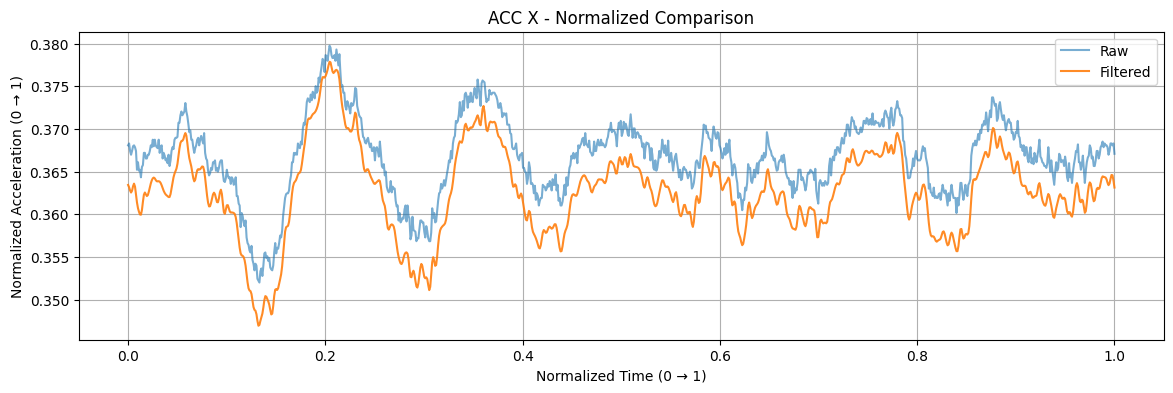

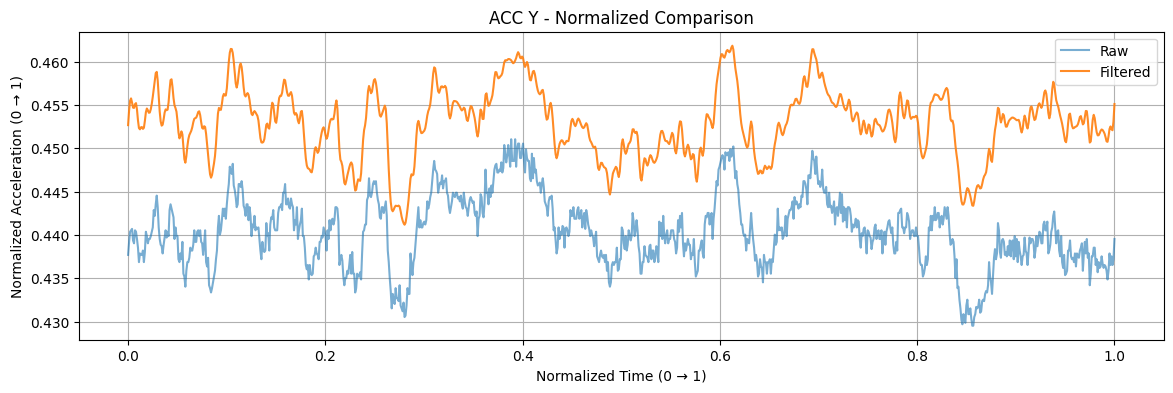

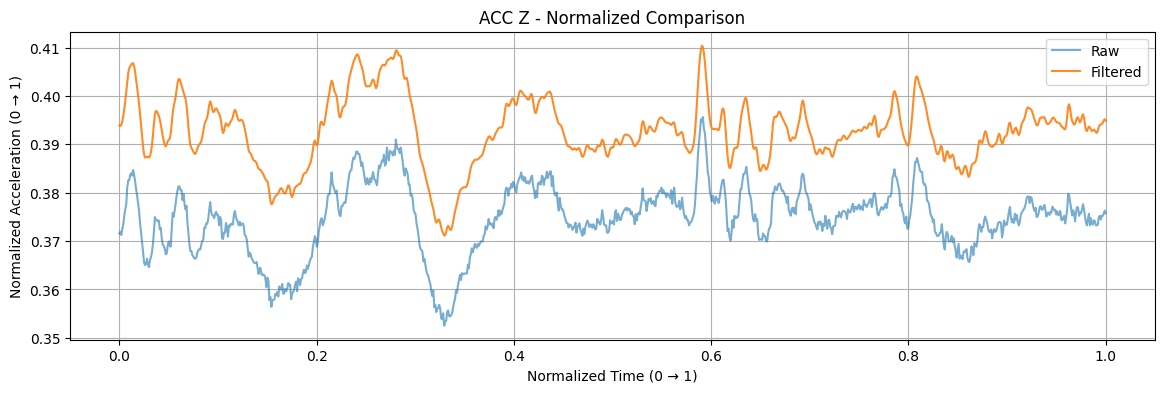

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. SAFE MIN-MAX NORMALIZATION
# =========================================================
def minmax(x):
    x = np.nan_to_num(x)
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-8)

# =========================================================
# 2. NORMALIZE ALL AXES
# =========================================================
acc_x_n = minmax(acc_x)
acc_y_n = minmax(acc_y)
acc_z_n = minmax(acc_z)

acc_xf_n = minmax(acc_x_f)
acc_yf_n = minmax(acc_y_f)
acc_zf_n = minmax(acc_z_f)

# =========================================================
# 3. PLOT FUNCTION
# =========================================================
def plot_axis(raw, filt, title):
    plt.figure(figsize=(14,4))

    # x-axis = normalized sample index
    x_axis = np.linspace(0, 1, len(raw[:1000]))

    plt.plot(x_axis, raw[:1000], label="Raw", alpha=0.6)
    plt.plot(x_axis, filt[:1000], label="Filtered", alpha=0.9)

    plt.title(title)
    plt.xlabel("Normalized Time (0 → 1)")
    plt.ylabel("Normalized Acceleration (0 → 1)")
    plt.legend()
    plt.grid()
    plt.show()

# =========================================================
# 4. PLOTS FOR X, Y, Z
# =========================================================
plot_axis(acc_x_n, acc_xf_n, "ACC X - Normalized Comparison")
plot_axis(acc_y_n, acc_yf_n, "ACC Y - Normalized Comparison")
plot_axis(acc_z_n, acc_zf_n, "ACC Z - Normalized Comparison")

In [49]:
import numpy as np
import pandas as pd

# =========================================================
# 1. BASIC METRICS FUNCTION
# =========================================================
def metrics(x):
    x = np.nan_to_num(x)

    return {
        "Mean": np.mean(x),
        "Std": np.std(x),
        "Noise": np.std(np.diff(x)),
        "Drift": np.mean(x) - np.median(x),
        "Outliers": np.sum(np.abs((x - np.mean(x)) / (np.std(x) + 1e-8)) > 3),
        "Slope Var": np.std(np.diff(x))
    }

# =========================================================
# 2. % CHANGE FUNCTION
# =========================================================
def pct_change(raw, filt):
    return ((filt - raw) / (raw + 1e-8)) * 100

# =========================================================
# 3. TABLE BUILDER (FOR ANY AXIS)
# =========================================================
def build_table(name, raw, filt):
    r = metrics(raw)
    f = metrics(filt)

    rows = []

    for k in r.keys():
        rows.append([
            f"{name}-{k}",
            r[k],
            f[k],
            pct_change(r[k], f[k])
        ])

    return pd.DataFrame(rows, columns=["Metric", "Raw", "Filtered", "% Change"])

# =========================================================
# 4. CREATE TABLES FOR X, Y, Z
# =========================================================
acc_x_table = build_table("ACC X", acc_x, acc_x_f)
acc_y_table = build_table("ACC Y", acc_y, acc_y_f)
acc_z_table = build_table("ACC Z", acc_z, acc_z_f)

# =========================================================
# 5. MERGE FINAL TABLE
# =========================================================
acc_quality_table = pd.concat(
    [acc_x_table, acc_y_table, acc_z_table],
    ignore_index=True
)

# =========================================================
# 6. DISPLAY
# =========================================================
pd.set_option("display.float_format", "{:.4f}".format)

print("\n=== ACC QUALITY METRICS TABLE ===\n")
print(acc_quality_table)

# optional save
acc_quality_table.to_csv("acc_quality_metrics.csv", index=False)


=== ACC QUALITY METRICS TABLE ===

             Metric        Raw   Filtered  % Change
0        ACC X-Mean 36795.6359    -0.0002 -100.0000
1         ACC X-Std   866.3968   126.0645  -85.4496
2       ACC X-Noise    10.5164     7.4446  -29.2100
3       ACC X-Drift  -507.3641     0.3209 -100.0632
4    ACC X-Outliers  3240.0000 60844.0000 1777.9012
5   ACC X-Slope Var    10.5164     7.4446  -29.2100
6        ACC Y-Mean 32333.3972     0.0002 -100.0000
7         ACC Y-Std   316.2120    76.1015  -75.9334
8       ACC Y-Noise     9.2784     5.8051  -37.4345
9       ACC Y-Drift   -36.6028     0.1244 -100.3398
10   ACC Y-Outliers 31668.0000 75654.0000  138.8973
11  ACC Y-Slope Var     9.2784     5.8051  -37.4345
12       ACC Z-Mean 30920.1572     0.0003 -100.0000
13        ACC Z-Std  1478.9737   100.0832  -93.2329
14      ACC Z-Noise    17.1304    11.6906  -31.7551
15      ACC Z-Drift  -505.8428     0.6902 -100.1364
16   ACC Z-Outliers  3054.0000 58620.0000 1819.4499
17  ACC Z-Slope Var    17.13

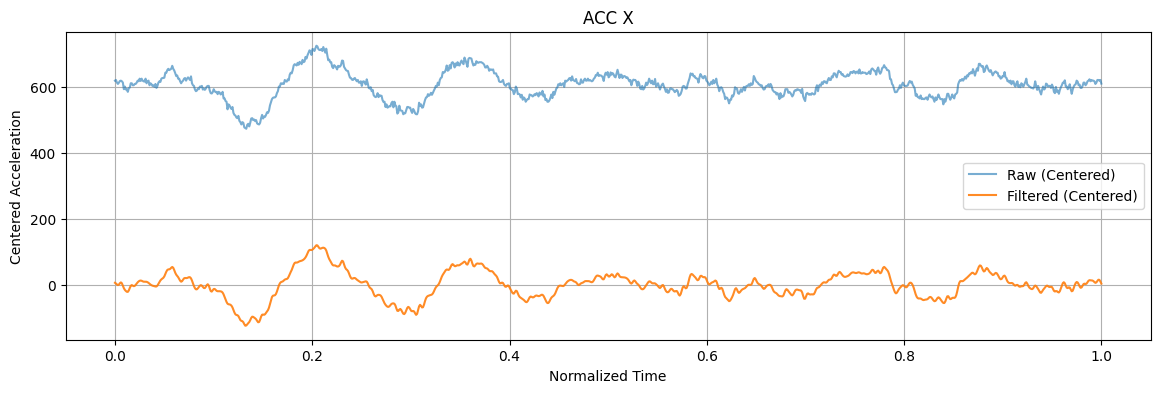

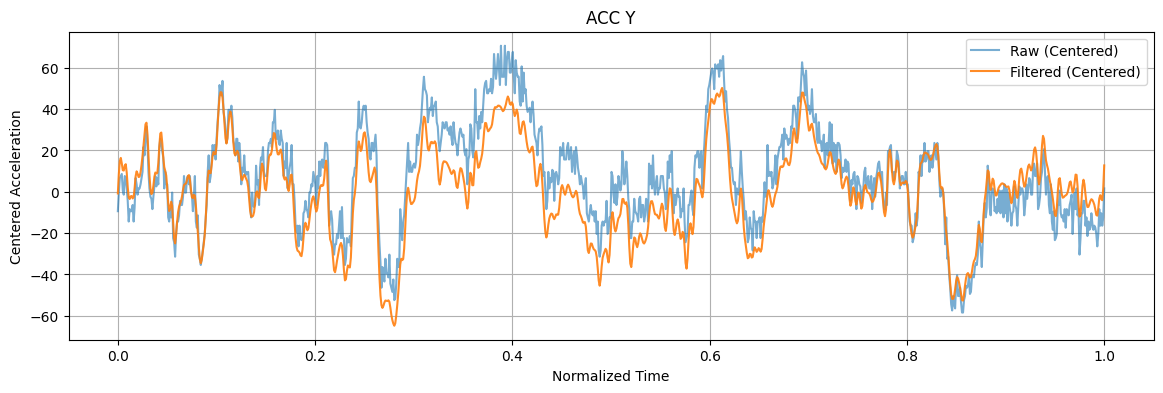

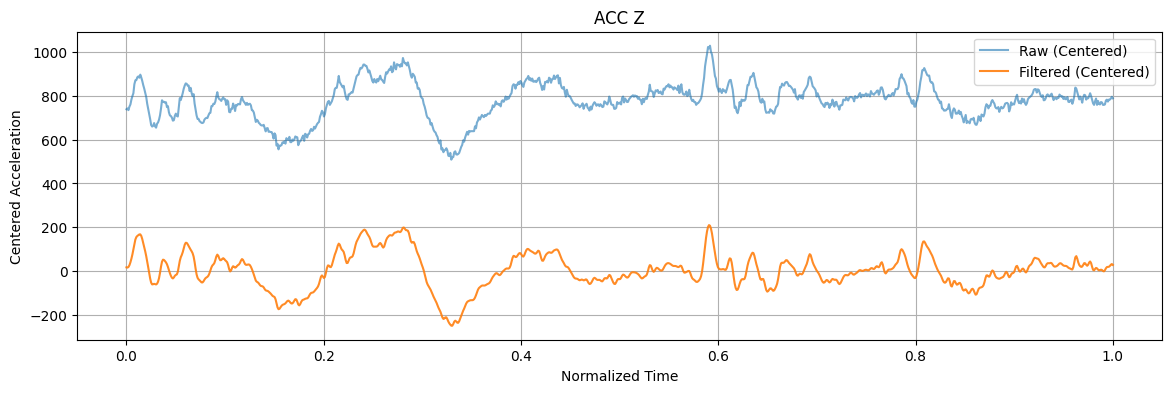

            Metric       Raw  Filtered      % Change
0       ACC X-Mean    0.0000   -0.0002 -1868429.7854
1        ACC X-Std  866.3968  126.0645      -85.4496
2      ACC X-Noise   10.5164    7.4446      -29.2100
3      ACC X-Drift -507.3641    0.3209     -100.0632
4  ACC X-Slope Var   10.5164    7.4446      -29.2100
0       ACC Y-Mean    0.0000    0.0002  1648483.7023
1        ACC Y-Std  316.2120   76.1015      -75.9334
2      ACC Y-Noise    9.2784    5.8051      -37.4345
3      ACC Y-Drift  -36.6028    0.1244     -100.3398
4  ACC Y-Slope Var    9.2784    5.8051      -37.4345
0       ACC Z-Mean    0.0000    0.0003  2982186.3375
1        ACC Z-Std 1478.9737  100.0832      -93.2329
2      ACC Z-Noise   17.1304   11.6906      -31.7551
3      ACC Z-Drift -505.8428    0.6902     -100.1364
4  ACC Z-Slope Var   17.1304   11.6906      -31.7551


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

 

acc_x = data.iloc[:, 6].values.astype(float)
acc_y = data.iloc[:, 7].values.astype(float)
acc_z = data.iloc[:, 8].values.astype(float)

# clean
acc_x = np.nan_to_num(acc_x)
acc_y = np.nan_to_num(acc_y)
acc_z = np.nan_to_num(acc_z)

# =========================================================
# 2. DC REMOVAL (DO THIS FIRST FOR BOTH)
# =========================================================
def remove_dc(x):
    return x - np.mean(x)

acc_x_dc = remove_dc(acc_x)
acc_y_dc = remove_dc(acc_y)
acc_z_dc = remove_dc(acc_z)

# =========================================================
# 3. FILTER (Bandpass for motion)
# =========================================================
def bandpass(x, fs=50, low=0.1, high=10):
    nyq = 0.5 * fs
    b, a = butter(3, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, x)

acc_x_f = bandpass(acc_x_dc)
acc_y_f = bandpass(acc_y_dc)
acc_z_f = bandpass(acc_z_dc)

# =========================================================
# 4. ALIGNMENT FIX (IMPORTANT)
#    → center BOTH signals for fair comparison
# =========================================================
def center(x):
    return x - np.mean(x)

acc_x_raw_plot = center(acc_x_dc)
acc_x_f_plot   = center(acc_x_f)

acc_y_raw_plot = center(acc_y_dc)
acc_y_f_plot   = center(acc_y_f)

acc_z_raw_plot = center(acc_z_dc)
acc_z_f_plot   = center(acc_z_f)

# =========================================================
# 5. PLOTS (NOW THEY WILL OVERLAP PROPERLY)
# =========================================================
def plot_axis(raw, filt, title):
    plt.figure(figsize=(14,4))
    x_axis = np.linspace(0, 1, len(raw[:1000]))

    plt.plot(x_axis, raw[:1000], label="Raw (Centered)", alpha=0.6)
    plt.plot(x_axis, filt[:1000], label="Filtered (Centered)", alpha=0.9)

    plt.title(title)
    plt.xlabel("Normalized Time")
    plt.ylabel("Centered Acceleration")
    plt.legend()
    plt.grid()
    plt.show()

plot_axis(acc_x_raw_plot, acc_x_f_plot, "ACC X")
plot_axis(acc_y_raw_plot, acc_y_f_plot, "ACC Y")
plot_axis(acc_z_raw_plot, acc_z_f_plot, "ACC Z")

# =========================================================
# 6. QUALITY METRICS (CORRECT SPACE)
# =========================================================
def metrics(x):
    x = np.nan_to_num(x)
    return {
        "Mean": np.mean(x),
        "Std": np.std(x),
        "Noise": np.std(np.diff(x)),
        "Drift": np.mean(x) - np.median(x),
        "Slope Var": np.std(np.diff(x)),
    }

def pct(r, f):
    return ((f - r) / (r + 1e-8)) * 100

def table(name, raw, filt):
    r = metrics(raw)
    f = metrics(filt)

    rows = []
    for k in r:
        rows.append([f"{name}-{k}", r[k], f[k], pct(r[k], f[k])])

    return pd.DataFrame(rows, columns=["Metric", "Raw", "Filtered", "% Change"])

acc_table = pd.concat([
    table("ACC X", acc_x_dc, acc_x_f),
    table("ACC Y", acc_y_dc, acc_y_f),
    table("ACC Z", acc_z_dc, acc_z_f)
])

print(acc_table)